# Transcription Accuracy — Session-Level Word Error Rate (WER)

Measures Word Error Rate for each transcription channel against YouTube subtitle ground truth.

**Channels:**
- **Deepgram Nova-3** — ASR engine via AudioHook proxy
- **Notifications (WebSocket)** — r2d2 ASR engine, delivered via Genesys Notifications API
- **EventBridge (SQS)** — r2d2 ASR engine, delivered via AWS EventBridge → SQS

**Engine vs Delivery Path distinction:**
- Deepgram Nova-3 vs r2d2 (Genesys) = **ASR engine comparison** (different models)
- Notifications vs EventBridge = **delivery path comparison** (same r2d2 engine)

**Methodology:**
- Session-level WER: concatenate all utterances per session, compute WER against concatenated SRT ground truth
- SRT files treated as perfect ground truth (will be rerun after manual verification)
- Standard WER via `jiwer`: WER = (S + D + I) / N where S=substitutions, D=deletions, I=insertions, N=reference words

---
## Cell 1: Setup & Configuration

In [1]:
import json
import re
import sys
import warnings
from datetime import datetime
from difflib import SequenceMatcher
from pathlib import Path

import jiwer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.correlate_latency import (
    load_deepgram_session,
    load_genesys_conversation,
    load_eventbridge_conversation,
    _normalize,
)

# === DIRECTORIES ===
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
NOTIF_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()
EB_EVENTS_DIR = (REPO_ROOT / "EventBridge" / "conversation_events").resolve()
SUBS_DIR = REPO_ROOT / "subs"
OUTPUT_DIR = REPO_ROOT / "analysis_results" / "transcription_accuracy"

SAVE_DPI = 300
NUM_RECENT = 6

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def parse_srt(path: Path) -> list[dict]:
    """Parse an SRT file into a list of {index, start_time, end_time, text} dicts.

    Handles multi-line text within a single subtitle block.
    """
    content = path.read_text(encoding="utf-8")
    blocks = re.split(r"\n\n+", content.strip())
    subtitles = []
    for block in blocks:
        lines = block.strip().splitlines()
        if len(lines) < 3:
            continue
        try:
            index = int(lines[0].strip())
        except ValueError:
            continue
        time_match = re.match(
            r"(\d{2}:\d{2}:\d{2}[,.]\d{3})\s*-->\s*(\d{2}:\d{2}:\d{2}[,.]\d{3})",
            lines[1].strip(),
        )
        if not time_match:
            continue
        text = " ".join(line.strip() for line in lines[2:])
        subtitles.append({
            "index": index,
            "start_time": time_match.group(1),
            "end_time": time_match.group(2),
            "text": text,
        })
    return subtitles


print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Deepgram results: {DEEPGRAM_RESULTS_DIR}")
print(f"SRT files: {SUBS_DIR}")

Repo root: /Users/xnxn040/PycharmProjects/notifications-spike
Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy
Deepgram results: /Users/xnxn040/PycharmProjects/poc-deepgram/results
SRT files: /Users/xnxn040/PycharmProjects/notifications-spike/subs


---
## Cell 2: Parse SRT Files

In [2]:
SRT_FILES = {
    "Cyrano": {"path": SUBS_DIR / "Cyrano.en.auto.srt", "srt_type": "auto"},
    "Glengarry": {"path": SUBS_DIR / "Glengarry.en.auto.srt", "srt_type": "auto"},
    "Mockingbird": {"path": SUBS_DIR / "Mockingbird.en.manual.srt", "srt_type": "manual"},
    "Shawshank": {"path": SUBS_DIR / "Shawshank.en.auto.srt", "srt_type": "auto"},
    "Iron Man": {"path": SUBS_DIR / "IronMan.en.auto.srt", "srt_type": "auto"},
}

srt_data = {}  # movie -> {subtitles, ground_truth_text, word_count, segment_count, srt_type}

for movie, info in SRT_FILES.items():
    srt_path = info["path"]
    if not srt_path.exists():
        print(f"WARNING: {srt_path} not found, skipping {movie}")
        continue
    subtitles = parse_srt(srt_path)
    ground_truth_text = _normalize(" ".join(s["text"] for s in subtitles))
    word_count = len(ground_truth_text.split())
    srt_data[movie] = {
        "subtitles": subtitles,
        "ground_truth_text": ground_truth_text,
        "word_count": word_count,
        "segment_count": len(subtitles),
        "srt_type": info["srt_type"],
    }

# Display summary
summary_rows = []
for movie, data in srt_data.items():
    summary_rows.append({
        "Movie": movie,
        "SRT Type": data["srt_type"],
        "Segments": data["segment_count"],
        "Words": data["word_count"],
    })
df_srt_summary = pd.DataFrame(summary_rows)
print("SRT Ground Truth Summary")
print("=" * 50)
print(df_srt_summary.to_string(index=False))
print(f"\nTotal: {len(srt_data)} movies, {sum(d['word_count'] for d in srt_data.values())} words")

SRT Ground Truth Summary
      Movie SRT Type  Segments  Words
     Cyrano     auto        66    444
  Glengarry     auto        67    485
Mockingbird   manual        34    227
  Shawshank     auto        39    209
   Iron Man     auto        28    157

Total: 5 movies, 1522 words


---
## Cell 3: Load All Channel Data

In [3]:
# --- File discovery (same as notebook-03) ---
dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)
notif_files = sorted(NOTIF_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)
eb_files = sorted(EB_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)

print(f"Available: {len(dg_files)} Deepgram, {len(notif_files)} Notifications, {len(eb_files)} EventBridge")


def get_dg_time_range(path):
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts


def get_jsonl_time_range(path):
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)


dg_recent = dg_files[:NUM_RECENT]
notif_recent = notif_files[:NUM_RECENT]
eb_recent = eb_files[:NUM_RECENT]

# Match Deepgram <-> Notifications by time overlap
notif_matched = []
used_notif = set()
for dg_path in dg_recent:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_idx, best_overlap = None, 0
    for j, nf in enumerate(notif_recent):
        if j in used_notif:
            continue
        nf_start, nf_end = get_jsonl_time_range(nf)
        overlap = max(0, min(dg_end, nf_end) - max(dg_start, nf_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j
    if best_idx is not None:
        notif_matched.append((dg_path, notif_recent[best_idx]))
        used_notif.add(best_idx)

# Match Notifications <-> EventBridge by conversation ID
eb_by_conv_id = {f.stem: f for f in eb_recent}

triple_matched = []
for dg_path, notif_path in notif_matched:
    conv_id = notif_path.stem
    eb_path = eb_by_conv_id.get(conv_id)
    triple_matched.append((dg_path, notif_path, eb_path))

print(f"Matched {len(triple_matched)} session triple(s)")

# --- Load all channel data per session ---
sessions = []  # list of dicts with all channel data

for dg_path, notif_path, eb_path in triple_matched:
    conv_id = notif_path.stem
    dg_events = load_deepgram_session(dg_path)
    notif_events = load_genesys_conversation(notif_path)
    eb_events = load_eventbridge_conversation(eb_path) if eb_path and eb_path.exists() else []

    # Concatenate all final utterance texts per channel
    dg_text = _normalize(" ".join(e.transcript for e in dg_events))
    notif_text = _normalize(" ".join(e.transcript for e in notif_events))
    eb_text = _normalize(" ".join(e.transcript for e in eb_events))

    # Average confidence per channel
    dg_conf = np.mean([e.confidence for e in dg_events]) if dg_events else 0.0
    notif_conf = np.mean([e.confidence for e in notif_events]) if notif_events else 0.0
    eb_conf = np.mean([e.confidence for e in eb_events]) if eb_events else 0.0

    sessions.append({
        "dg_path": dg_path,
        "notif_path": notif_path,
        "eb_path": eb_path,
        "conv_id": conv_id,
        "dg_text": dg_text,
        "notif_text": notif_text,
        "eb_text": eb_text,
        "dg_events": dg_events,
        "notif_events": notif_events,
        "eb_events": eb_events,
        "dg_confidence": dg_conf,
        "notif_confidence": notif_conf,
        "eb_confidence": eb_conf,
        "dg_utterance_count": len(dg_events),
        "notif_utterance_count": len(notif_events),
        "eb_utterance_count": len(eb_events),
    })

for s in sessions:
    print(
        f"  {s['dg_path'].name} | conv={s['conv_id'][:8]}... | "
        f"DG={s['dg_utterance_count']} Notif={s['notif_utterance_count']} EB={s['eb_utterance_count']} utterances"
    )

Available: 6 Deepgram, 6 Notifications, 6 EventBridge
Matched 6 session triple(s)
  nova-3_2026-03-21T01-14-22Z.json | conv=ccb202d4... | DG=19 Notif=10 EB=11 utterances
  nova-3_2026-03-21T01-08-57Z.json | conv=62ea6595... | DG=33 Notif=31 EB=31 utterances
  nova-3_2026-03-21T01-04-49Z.json | conv=ecb7785a... | DG=34 Notif=30 EB=30 utterances
  nova-3_2026-03-21T00-59-23Z.json | conv=9fb83242... | DG=53 Notif=32 EB=33 utterances
  nova-3_2026-03-21T00-53-40Z.json | conv=b986f068... | DG=49 Notif=27 EB=27 utterances
  nova-3_2026-03-21T00-40-56Z.json | conv=a9708b9e... | DG=22 Notif=13 EB=13 utterances


---
## Cell 4: Map Sessions to Movies

In [4]:
# Known mapping from plan (verified via notebook-03 time-overlap matching)
CONV_ID_TO_MOVIE = {
    "a9708b9e-39fb-4de9-8060-d8bdda444a5d": None,  # Maleficent — no SRT
    "b986f068-1f3f-4bb2-8519-505e7516af2a": "Cyrano",
    "9fb83242-e353-4020-a105-07cc714d362e": "Glengarry",
    "ecb7785a-f230-44ef-8cc8-ee1007a04578": "Mockingbird",
    "62ea6595-667f-4215-a252-12e13204ced0": "Shawshank",
    "ccb202d4-e2a9-4e9d-8c02-183f5bd418ab": "Iron Man",
}

# Keyword anchors: 5 distinctive words per movie (unique or near-unique to that SRT)
# Selected by frequency in the target SRT and rarity across all other SRTs
MOVIE_ANCHORS = {
    "Cyrano": ["nose", "sir", "small", "rather", "staring"],
    "Glengarry": ["prize", "close", "weak", "sell", "attention"],
    "Mockingbird": ["gentlemen", "negro", "courts", "assumption", "negroes"],
    "Shawshank": ["rehabilitated", "sunny", "kid", "stamp", "sorry"],
    "Iron Man": ["superhero", "stark", "bodyguard", "iron", "rooftop"],
}


def keyword_anchor_score(text: str, anchors: list[str]) -> tuple[int, int, list[str]]:
    """Count how many anchor keywords appear in the text.

    Returns (hits, total, matched_words).
    """
    words = set(text.split())
    matched = [a for a in anchors if a in words]
    return len(matched), len(anchors), matched


# Map sessions using known conversation IDs (primary), verify with keyword anchors
mapping_rows = []
session_movie_map = {}  # session index -> movie name

for i, session in enumerate(sessions):
    conv_id = session["conv_id"]
    known_movie = CONV_ID_TO_MOVIE.get(conv_id)

    # Keyword anchor verification against Deepgram text (best ASR quality)
    anchor_results = {}
    best_anchor_movie = None
    best_anchor_hits = 0
    for movie, anchors in MOVIE_ANCHORS.items():
        hits, total, matched = keyword_anchor_score(session["dg_text"], anchors)
        anchor_results[movie] = (hits, total, matched)
        if hits > best_anchor_hits:
            best_anchor_hits = hits
            best_anchor_movie = movie

    # Format anchor verification
    if known_movie and known_movie in anchor_results:
        hits, total, matched = anchor_results[known_movie]
        anchor_str = f"{hits}/{total} [{', '.join(matched)}]" if matched else f"0/{total}"
    else:
        anchor_str = "N/A (skip)"

    # Use known mapping
    session_movie_map[i] = known_movie

    verified = "SKIP"
    if known_movie is not None:
        if known_movie == best_anchor_movie:
            verified = "VERIFIED"
        elif best_anchor_hits == 0:
            verified = "NO ANCHORS"
        else:
            verified = f"MISMATCH (best={best_anchor_movie} {best_anchor_hits}/{len(MOVIE_ANCHORS[best_anchor_movie])})"

    mapping_rows.append({
        "Session": session["dg_path"].name,
        "Conv ID": conv_id[:8] + "...",
        "Known Movie": known_movie if known_movie else "(Maleficent/SKIP)",
        "Anchor Hits": anchor_str,
        "Best Anchor": best_anchor_movie if best_anchor_movie else "—",
        "Status": verified,
        "DG Words": len(session["dg_text"].split()),
    })

df_mapping = pd.DataFrame(mapping_rows)
print("SESSION → MOVIE MAPPING (keyword anchor verification)")
print("=" * 130)
print(df_mapping.to_string(index=False))

# Count mapped vs unmapped
mapped_count = sum(1 for v in session_movie_map.values() if v is not None)
unmapped_count = sum(1 for v in session_movie_map.values() if v is None)
print(f"\nMapped: {mapped_count} sessions, Excluded: {unmapped_count} sessions (no SRT)")

# Report verification results
verified_count = sum(1 for r in mapping_rows if r["Status"] == "VERIFIED")
mismatch_rows = [r for r in mapping_rows if "MISMATCH" in r["Status"]]
print(f"Verified by anchors: {verified_count}/{mapped_count}")
if mismatch_rows:
    print(f"\nWARNING: {len(mismatch_rows)} mapping(s) not verified by keyword anchors:")
    for m in mismatch_rows:
        print(f"  {m['Session']}: known={m['Known Movie']}, {m['Status']}")
    print("  (Known mapping from time-overlap is authoritative — anchor mismatch may indicate SRT quality issues)")

SESSION → MOVIE MAPPING (keyword anchor verification)
                         Session     Conv ID       Known Movie                                      Anchor Hits Best Anchor   Status  DG Words
nova-3_2026-03-21T01-14-22Z.json ccb202d4...          Iron Man 5/5 [superhero, stark, bodyguard, iron, rooftop]    Iron Man VERIFIED       159
nova-3_2026-03-21T01-08-57Z.json 62ea6595...         Shawshank           4/5 [rehabilitated, kid, stamp, sorry]   Shawshank VERIFIED       196
nova-3_2026-03-21T01-04-49Z.json ecb7785a...       Mockingbird       4/5 [gentlemen, negro, courts, assumption] Mockingbird VERIFIED       211
nova-3_2026-03-21T00-59-23Z.json 9fb83242...         Glengarry               4/5 [close, weak, sell, attention]   Glengarry VERIFIED       448
nova-3_2026-03-21T00-53-40Z.json b986f068...            Cyrano          5/5 [nose, sir, small, rather, staring]      Cyrano VERIFIED       432
nova-3_2026-03-21T00-40-56Z.json a9708b9e... (Maleficent/SKIP)                          

---
## Cell 5: Session-Level WER (Primary Analysis)

In [5]:
wer_rows = []

for i, session in enumerate(sessions):
    movie = session_movie_map.get(i)
    if movie is None:
        continue

    reference = srt_data[movie]["ground_truth_text"]
    ref_word_count = len(reference.split())

    channels = [
        ("Deepgram", session["dg_text"], session["dg_confidence"]),
        ("Notifications", session["notif_text"], session["notif_confidence"]),
        ("EventBridge", session["eb_text"], session["eb_confidence"]),
    ]

    for channel_name, hypothesis, confidence in channels:
        if not hypothesis.strip():
            continue

        wer_score = jiwer.wer(reference, hypothesis)
        measures = jiwer.process_words(reference, hypothesis)

        wer_rows.append({
            "movie": movie,
            "srt_type": srt_data[movie]["srt_type"],
            "channel": channel_name,
            "conv_id": session["conv_id"],
            "dg_session": session["dg_path"].name,
            "wer": wer_score,
            "substitutions": measures.substitutions,
            "deletions": measures.deletions,
            "insertions": measures.insertions,
            "hits": measures.hits,
            "ref_words": ref_word_count,
            "hyp_words": len(hypothesis.split()),
            "confidence": confidence,
            "reference": reference,
            "hypothesis": hypothesis,
        })

df_wer = pd.DataFrame(wer_rows)

# Summary table: WER per channel per movie
print("SESSION-LEVEL WER BY CHANNEL AND MOVIE")
print("=" * 100)

pivot = df_wer.pivot_table(
    index="movie", columns="channel", values="wer", aggfunc="first"
)[["Deepgram", "Notifications", "EventBridge"]]

# Format as percentage
print(pivot.map(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A").to_string())

# Weighted average WER per channel
print("\nWEIGHTED AVERAGE WER (weighted by reference word count)")
print("-" * 80)
print("  Formula: Weighted WER = sum(S + D + I across all sessions) / sum(N across all sessions)")
print("  where S=substitutions, D=deletions, I=insertions, N=reference word count per session")
print("")
print("  This weights longer sessions proportionally \u2014 a 485-word session (Glengarry)")
print("  contributes ~3x more than a 157-word session (Iron Man). Equivalent to computing")
print("  WER on all sessions concatenated into a single reference/hypothesis pair.")
print("-" * 80)
for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch_data = df_wer[df_wer["channel"] == channel]
    if ch_data.empty:
        continue
    total_s = int(ch_data["substitutions"].sum())
    total_d = int(ch_data["deletions"].sum())
    total_i = int(ch_data["insertions"].sum())
    total_errors = total_s + total_d + total_i
    total_ref_words = int(ch_data["ref_words"].sum())
    weighted_wer = total_errors / total_ref_words if total_ref_words > 0 else 0
    print(f"  {channel:<15} = ({total_s} + {total_d} + {total_i}) / {total_ref_words}"
          f"  =  {total_errors}/{total_ref_words}"
          f"  =  {weighted_wer:.1%}")

# Engine vs delivery path framing
print("\nENGINE COMPARISON (Deepgram Nova-3 vs r2d2):")
dg_wers = df_wer[df_wer["channel"] == "Deepgram"]["wer"]
notif_wers = df_wer[df_wer["channel"] == "Notifications"]["wer"]
if not dg_wers.empty and not notif_wers.empty:
    print(f"  Deepgram mean WER: {dg_wers.mean():.1%}, Notifications mean WER: {notif_wers.mean():.1%}")

print("\nDELIVERY PATH COMPARISON (Notifications vs EventBridge):")
eb_wers = df_wer[df_wer["channel"] == "EventBridge"]["wer"]
if not notif_wers.empty and not eb_wers.empty:
    print(f"  Notifications mean WER: {notif_wers.mean():.1%}, EventBridge mean WER: {eb_wers.mean():.1%}")
    diff = abs(notif_wers.mean() - eb_wers.mean())
    print(f"  Absolute difference: {diff:.4%}")

SESSION-LEVEL WER BY CHANNEL AND MOVIE
channel     Deepgram Notifications EventBridge
movie                                         
Cyrano         24.8%         28.2%       28.2%
Glengarry      29.9%         40.6%       39.0%
Iron Man       17.2%         42.7%       42.0%
Mockingbird    28.6%         45.8%       45.8%
Shawshank      30.6%         42.6%       42.6%

WEIGHTED AVERAGE WER (weighted by reference word count)
--------------------------------------------------------------------------------
  Formula: Weighted WER = sum(S + D + I across all sessions) / sum(N across all sessions)
  where S=substitutions, D=deletions, I=insertions, N=reference word count per session

  This weights longer sessions proportionally — a 485-word session (Glengarry)
  contributes ~3x more than a 157-word session (Iron Man). Equivalent to computing
  WER on all sessions concatenated into a single reference/hypothesis pair.
------------------------------------------------------------------------------

---
## Cell 5b: Deeper WER Analysis — Error Breakdown & Alignment Inspection

Beyond the aggregate WER score:
- **Error type breakdown**: % substitutions vs deletions vs insertions per channel — pinpoints model weaknesses
- **Word-level alignment**: Levenshtein-based alignment showing exactly where each error occurs
- **Per-category analysis**: Classifies errors into numbers, proper nouns/entities, and common words

ERROR TYPE BREAKDOWN BY CHANNEL
Channel               Substitutions    Deletions   Insertions   Total Errors
------------------------------------------------------------------------------------------
  Deepgram              247 (60.1%)    120 (29.2%)     44 (10.7%)     411
  Notifications         289 (49.7%)    272 (46.7%)     21 ( 3.6%)     582
  EventBridge           293 (51.1%)    257 (44.9%)     23 ( 4.0%)     573


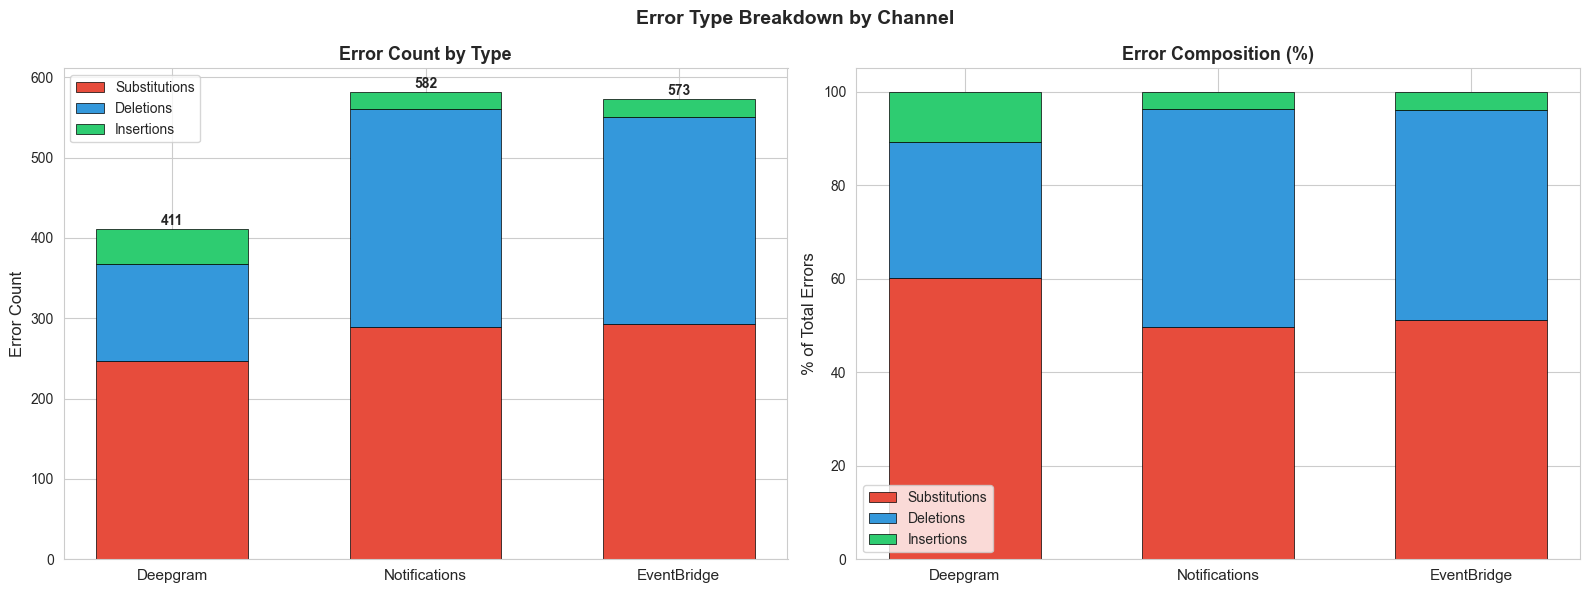



WORD-LEVEL ALIGNMENT — WORST WER PER CHANNEL

  Deepgram — worst: Shawshank (WER=30.6%)
  Type  Reference                 Hypothesis                Category    
  ----------------------------------------------------------------------
  INS   ∅                         say                       common      
  INS   ∅                         less                      common      
  INS   ∅                         force                     common      
  INS   ∅                         test                      common      
  SUB   please                    call                      common      
  SUB   sit                       that                      common      
  SUB   down                      is                        common      
  SUB   ellis                     the                       common      
  SUB   boyd                      board                     common      
  SUB   reading                   ready                     common      
  SUB   say                       

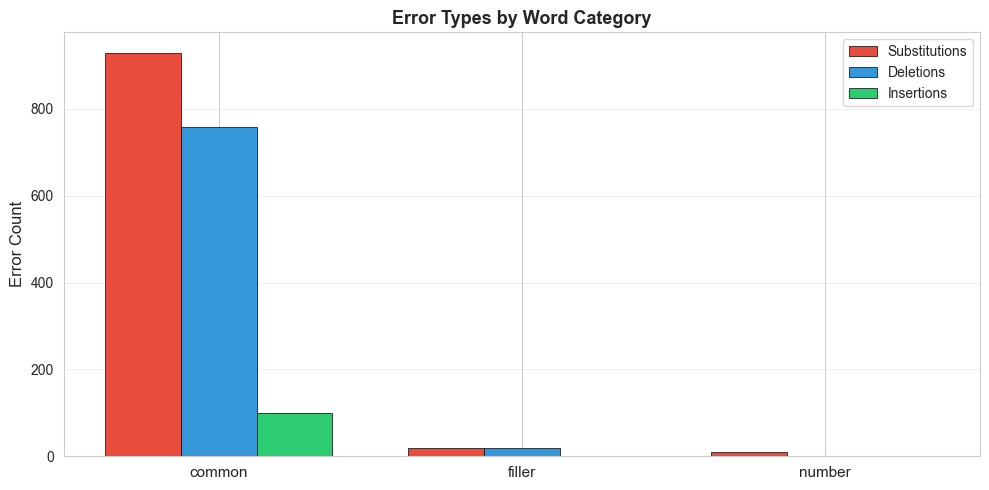

In [6]:
# === ERROR TYPE BREAKDOWN ===
print("ERROR TYPE BREAKDOWN BY CHANNEL")
print("=" * 90)
print(f"{'Channel':<20} {'Substitutions':>14} {'Deletions':>12} {'Insertions':>12} {'Total Errors':>14}")
print("-" * 90)

error_breakdown_rows = []
for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch = df_wer[df_wer["channel"] == channel]
    if ch.empty:
        continue
    total_s = ch["substitutions"].sum()
    total_d = ch["deletions"].sum()
    total_i = ch["insertions"].sum()
    total_e = total_s + total_d + total_i
    pct_s = total_s / total_e * 100 if total_e > 0 else 0
    pct_d = total_d / total_e * 100 if total_e > 0 else 0
    pct_i = total_i / total_e * 100 if total_e > 0 else 0
    print(f"  {channel:<18} {total_s:>6} ({pct_s:>4.1f}%)  {total_d:>5} ({pct_d:>4.1f}%)  "
          f"{total_i:>5} ({pct_i:>4.1f}%)  {total_e:>6}")
    error_breakdown_rows.append({
        "Channel": channel,
        "Substitutions": total_s, "Sub %": pct_s,
        "Deletions": total_d, "Del %": pct_d,
        "Insertions": total_i, "Ins %": pct_i,
        "Total": total_e,
    })

# Stacked bar chart: error composition per channel
if error_breakdown_rows:
    df_err = pd.DataFrame(error_breakdown_rows)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Absolute counts
    ax = axes[0]
    x = np.arange(len(df_err))
    w = 0.6
    ax.bar(x, df_err["Substitutions"], w, label="Substitutions", color="#e74c3c", edgecolor="black", linewidth=0.5)
    ax.bar(x, df_err["Deletions"], w, bottom=df_err["Substitutions"], label="Deletions",
           color="#3498db", edgecolor="black", linewidth=0.5)
    ax.bar(x, df_err["Insertions"], w,
           bottom=df_err["Substitutions"] + df_err["Deletions"],
           label="Insertions", color="#2ecc71", edgecolor="black", linewidth=0.5)
    for i, row in df_err.iterrows():
        ax.text(i, row["Total"] + 5, str(row["Total"]), ha="center", fontweight="bold", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(df_err["Channel"], fontsize=11)
    ax.set_ylabel("Error Count", fontsize=12)
    ax.set_title("Error Count by Type", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)

    # Right: Percentage composition
    ax = axes[1]
    ax.bar(x, df_err["Sub %"], w, label="Substitutions", color="#e74c3c", edgecolor="black", linewidth=0.5)
    ax.bar(x, df_err["Del %"], w, bottom=df_err["Sub %"], label="Deletions",
           color="#3498db", edgecolor="black", linewidth=0.5)
    ax.bar(x, df_err["Ins %"], w,
           bottom=df_err["Sub %"] + df_err["Del %"],
           label="Insertions", color="#2ecc71", edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(df_err["Channel"], fontsize=11)
    ax.set_ylabel("% of Total Errors", fontsize=12)
    ax.set_title("Error Composition (%)", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=10)

    fig.suptitle("Error Type Breakdown by Channel", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "error_type_breakdown.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()


# === WORD-LEVEL ALIGNMENT INSPECTION ===
# Show alignment for the worst WER per channel (most informative)
print("\n\nWORD-LEVEL ALIGNMENT — WORST WER PER CHANNEL")
print("=" * 90)

NUMBER_PATTERN = re.compile(r"^\d+$|^\d+[\d,.]+\d+$")
# Common filler/stop words that are less interesting when misrecognized
FILLER_WORDS = {"uh", "um", "oh", "ah", "hmm", "huh", "well", "like", "you know", "i mean"}


def classify_word(word):
    """Classify a word into a category for error analysis."""
    if NUMBER_PATTERN.match(word):
        return "number"
    if word and word[0].isupper():
        return "proper_noun"
    if word in FILLER_WORDS:
        return "filler"
    return "common"


def format_alignment(ref_words, hyp_words, alignments, max_errors=20):
    """Format word-level alignment showing errors inline."""
    lines = []
    error_details = []  # (type, ref_word, hyp_word, category)
    error_count = 0

    for chunk in alignments:
        if chunk.type == "equal":
            continue
        elif chunk.type == "substitute":
            for ri, hi in zip(
                range(chunk.ref_start_idx, chunk.ref_end_idx),
                range(chunk.hyp_start_idx, chunk.hyp_end_idx),
            ):
                ref_w = ref_words[ri]
                hyp_w = hyp_words[hi]
                cat = classify_word(ref_w)
                error_details.append(("SUB", ref_w, hyp_w, cat))
                error_count += 1
        elif chunk.type == "delete":
            for ri in range(chunk.ref_start_idx, chunk.ref_end_idx):
                ref_w = ref_words[ri]
                cat = classify_word(ref_w)
                error_details.append(("DEL", ref_w, "∅", cat))
                error_count += 1
        elif chunk.type == "insert":
            for hi in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                hyp_w = hyp_words[hi]
                cat = classify_word(hyp_w)
                error_details.append(("INS", "∅", hyp_w, cat))
                error_count += 1

    # Print error table (capped at max_errors)
    lines.append(f"  {'Type':<5} {'Reference':<25} {'Hypothesis':<25} {'Category':<12}")
    lines.append(f"  {'-' * 70}")
    for etype, ref_w, hyp_w, cat in error_details[:max_errors]:
        lines.append(f"  {etype:<5} {ref_w:<25} {hyp_w:<25} {cat:<12}")
    if len(error_details) > max_errors:
        lines.append(f"  ... and {len(error_details) - max_errors} more errors")

    return "\n".join(lines), error_details


all_error_details = []  # Collect for per-category analysis

for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch = df_wer[df_wer["channel"] == channel]
    if ch.empty:
        continue
    worst = ch.loc[ch["wer"].idxmax()]
    print(f"\n  {channel} — worst: {worst['movie']} (WER={worst['wer']:.1%})")

    measures = jiwer.process_words(worst["reference"], worst["hypothesis"])
    ref_words = measures.references[0]
    hyp_words = measures.hypotheses[0]
    alignment_text, errors = format_alignment(ref_words, hyp_words, measures.alignments[0])
    print(alignment_text)

    for etype, ref_w, hyp_w, cat in errors:
        all_error_details.append({
            "channel": channel, "movie": worst["movie"],
            "type": etype, "ref": ref_w, "hyp": hyp_w, "category": cat,
        })

# Also collect errors from ALL sessions (not just worst)
for _, row in df_wer.iterrows():
    if row["wer"] == 0:
        continue
    measures = jiwer.process_words(row["reference"], row["hypothesis"])
    ref_words = measures.references[0]
    hyp_words = measures.hypotheses[0]
    _, errors = format_alignment(ref_words, hyp_words, measures.alignments[0], max_errors=9999)
    for etype, ref_w, hyp_w, cat in errors:
        all_error_details.append({
            "channel": row["channel"], "movie": row["movie"],
            "type": etype, "ref": ref_w, "hyp": hyp_w, "category": cat,
        })

df_errors = pd.DataFrame(all_error_details)


# === PER-CATEGORY ERROR ANALYSIS ===
print("\n\nPER-CATEGORY ERROR ANALYSIS (all sessions)")
print("=" * 70)

if not df_errors.empty:
    cat_summary = df_errors.groupby("category").agg(
        count=("type", "size"),
        substitutions=("type", lambda x: (x == "SUB").sum()),
        deletions=("type", lambda x: (x == "DEL").sum()),
        insertions=("type", lambda x: (x == "INS").sum()),
    )
    cat_summary["pct_of_total"] = cat_summary["count"] / cat_summary["count"].sum() * 100
    cat_summary = cat_summary.sort_values("count", ascending=False)
    print(cat_summary.to_string())

    # Top substitution pairs (what gets confused with what)
    subs = df_errors[df_errors["type"] == "SUB"]
    if not subs.empty:
        print("\n\nTOP 15 SUBSTITUTION PAIRS (ref → hyp)")
        print("-" * 50)
        sub_pairs = subs.groupby(["ref", "hyp"]).size().sort_values(ascending=False).head(15)
        for (ref_w, hyp_w), count in sub_pairs.items():
            cat = classify_word(ref_w)
            print(f"  {ref_w:<20} → {hyp_w:<20} (×{count}, {cat})")

    # Per-category breakdown chart
    if len(cat_summary) > 1:
        fig, ax = plt.subplots(figsize=(10, 5))
        cats = cat_summary.index.tolist()
        x = np.arange(len(cats))
        w = 0.25
        ax.bar(x - w, cat_summary["substitutions"], w, label="Substitutions", color="#e74c3c",
               edgecolor="black", linewidth=0.5)
        ax.bar(x, cat_summary["deletions"], w, label="Deletions", color="#3498db",
               edgecolor="black", linewidth=0.5)
        ax.bar(x + w, cat_summary["insertions"], w, label="Insertions", color="#2ecc71",
               edgecolor="black", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(cats, fontsize=11)
        ax.set_ylabel("Error Count", fontsize=12)
        ax.set_title("Error Types by Word Category", fontsize=13, fontweight="bold")
        ax.legend(fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "error_by_category.png", dpi=SAVE_DPI, bbox_inches="tight")
        plt.show()
else:
    print("No errors to categorize (all WER = 0).")

---
## Cell 6: Dropped Utterance Detection (Notifications vs EventBridge)

**Scope: Notif vs EB only** — both use the r2d2 engine, so utterance segmentation is comparable. Deepgram Nova-3 segments audio differently and is not comparable at the utterance level.

In [7]:
MATCH_THRESHOLD = 0.70

dropped_rows = []

for i, session in enumerate(sessions):
    movie = session_movie_map.get(i)
    label = movie if movie else session["dg_path"].name

    notif_events = session["notif_events"]
    eb_events = session["eb_events"]

    notif_texts = [_normalize(e.transcript) for e in notif_events]
    eb_texts = [_normalize(e.transcript) for e in eb_events]

    # Match Notif -> EB by text similarity
    matched_notif = set()
    matched_eb = set()

    for ni, nt in enumerate(notif_texts):
        best_ei, best_sim = None, 0.0
        for ei, et in enumerate(eb_texts):
            if ei in matched_eb:
                continue
            sim = SequenceMatcher(None, nt, et).ratio()
            if sim > best_sim:
                best_sim = sim
                best_ei = ei
        if best_ei is not None and best_sim >= MATCH_THRESHOLD:
            matched_notif.add(ni)
            matched_eb.add(best_ei)

    # Unmatched in Notifications (present in Notif, missing from EB)
    for ni, nt in enumerate(notif_texts):
        if ni not in matched_notif and nt.strip():
            dropped_rows.append({
                "session": label,
                "conv_id": session["conv_id"][:8],
                "missing_from": "EventBridge",
                "text": nt[:80],
                "utterance_id": notif_events[ni].utterance_id[:8] if notif_events[ni].utterance_id else "",
            })

    # Unmatched in EventBridge (present in EB, missing from Notif)
    for ei, et in enumerate(eb_texts):
        if ei not in matched_eb and et.strip():
            dropped_rows.append({
                "session": label,
                "conv_id": session["conv_id"][:8],
                "missing_from": "Notifications",
                "text": et[:80],
                "utterance_id": eb_events[ei].utterance_id[:8] if eb_events[ei].utterance_id else "",
            })

df_dropped = pd.DataFrame(dropped_rows)

print("DROPPED UTTERANCE DETECTION (Notifications vs EventBridge)")
print("=" * 80)

if df_dropped.empty:
    print("No dropped utterances detected — all utterances matched between Notif and EB.")
else:
    print(f"Total dropped: {len(df_dropped)}")
    print(f"\nBy delivery path:")
    print(df_dropped["missing_from"].value_counts().to_string())
    print(f"\nBy session:")
    print(df_dropped.groupby(["session", "missing_from"]).size().to_string())
    print(f"\nDropped utterances:")
    print(df_dropped.to_string(index=False))

DROPPED UTTERANCE DETECTION (Notifications vs EventBridge)
Total dropped: 2

By delivery path:
missing_from
Notifications    2

By session:
session    missing_from 
Glengarry  Notifications    1
Iron Man   Notifications    1

Dropped utterances:
  session  conv_id  missing_from                                                text utterance_id
 Iron Man ccb202d4 Notifications                                     i am a hard mat     f654ba2f
Glengarry 9fb83242 Notifications moneys out there you pick it up as sure if you dont     a40bb059


---
## Cell 7: Notifications vs EventBridge Text Identity

Both channels use the same r2d2 ASR engine — matched pairs should have identical transcripts. Any differences indicate delivery path corruption.

In [8]:
identity_rows = []
total_pairs = 0
identical_pairs = 0

for i, session in enumerate(sessions):
    movie = session_movie_map.get(i)
    label = movie if movie else session["dg_path"].name

    notif_events = session["notif_events"]
    eb_events = session["eb_events"]

    notif_texts = [_normalize(e.transcript) for e in notif_events]
    eb_texts = [_normalize(e.transcript) for e in eb_events]

    # Match by text similarity
    matched_eb_set = set()
    for ni, nt in enumerate(notif_texts):
        best_ei, best_sim = None, 0.0
        for ei, et in enumerate(eb_texts):
            if ei in matched_eb_set:
                continue
            sim = SequenceMatcher(None, nt, et).ratio()
            if sim > best_sim:
                best_sim = sim
                best_ei = ei
        if best_ei is not None and best_sim >= MATCH_THRESHOLD:
            matched_eb_set.add(best_ei)
            total_pairs += 1
            if nt == eb_texts[best_ei]:
                identical_pairs += 1
            else:
                identity_rows.append({
                    "session": label,
                    "notif_text": nt[:60],
                    "eb_text": eb_texts[best_ei][:60],
                    "similarity": f"{best_sim:.3f}",
                })

print("NOTIFICATIONS vs EVENTBRIDGE TEXT IDENTITY")
print("=" * 80)
print(f"Total matched pairs: {total_pairs}")
print(f"Identical: {identical_pairs} ({identical_pairs/total_pairs*100:.1f}%)" if total_pairs > 0 else "No pairs")
print(f"Different: {len(identity_rows)} ({len(identity_rows)/total_pairs*100:.1f}%)" if total_pairs > 0 else "")

if identity_rows:
    print(f"\nText differences:")
    df_identity = pd.DataFrame(identity_rows)
    print(df_identity.to_string(index=False))
else:
    print("\nAll matched pairs have identical text — no delivery path corruption detected.")

NOTIFICATIONS vs EVENTBRIDGE TEXT IDENTITY
Total matched pairs: 143
Identical: 143 (100.0%)
Different: 0 (0.0%)

All matched pairs have identical text — no delivery path corruption detected.


---
## Cell 8: WER vs Confidence Correlation

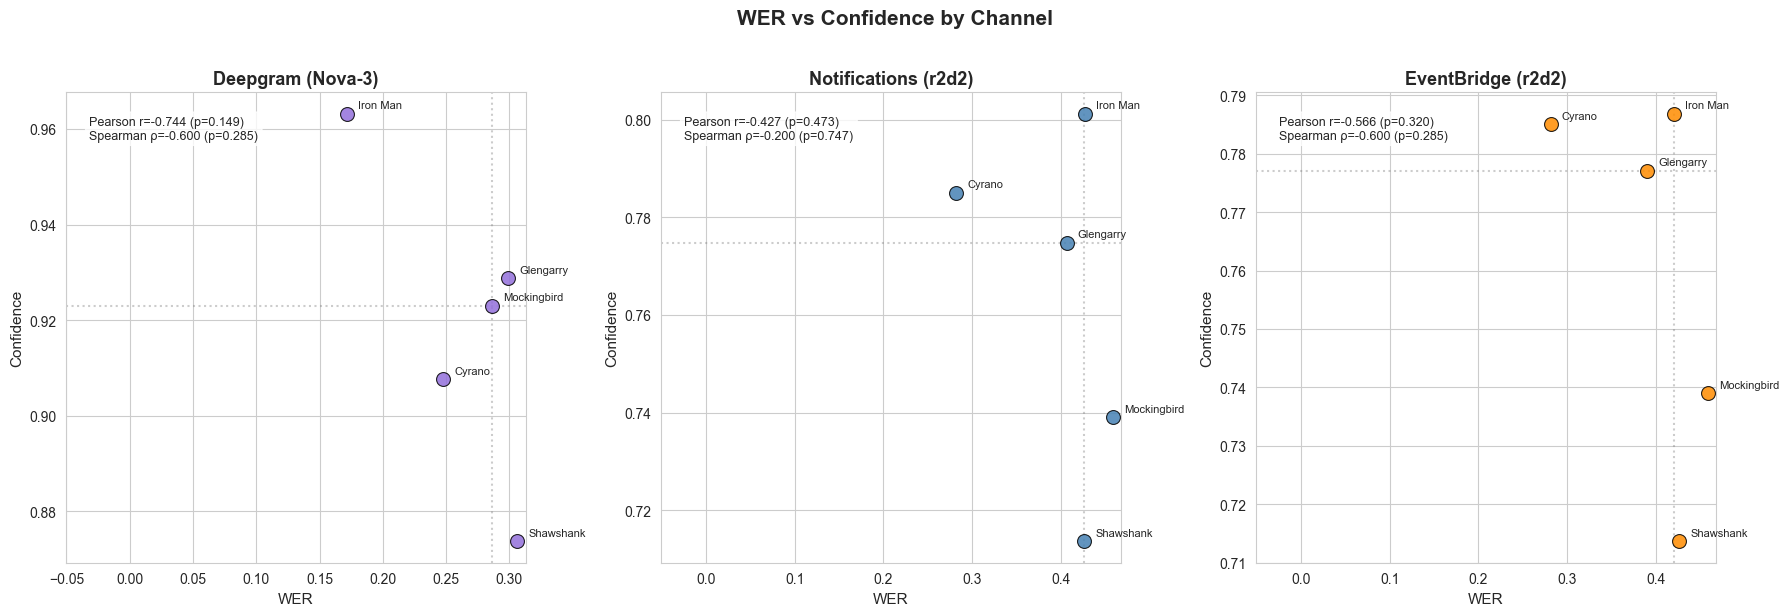


WER vs CONFIDENCE CORRELATION SUMMARY
  Deepgram             Pearson r=-0.744 (p=0.149)  Spearman ρ=-0.600 (p=0.285)
  Notifications        Pearson r=-0.427 (p=0.473)  Spearman ρ=-0.200 (p=0.747)
  EventBridge          Pearson r=-0.566 (p=0.320)  Spearman ρ=-0.600 (p=0.285)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

channel_colors = {"Deepgram": "mediumpurple", "Notifications": "steelblue", "EventBridge": "darkorange"}

for idx, channel in enumerate(["Deepgram", "Notifications", "EventBridge"]):
    ax = axes[idx]
    ch_data = df_wer[df_wer["channel"] == channel].copy()

    if ch_data.empty:
        ax.set_title(f"{channel} — No Data")
        continue

    x = ch_data["wer"].values
    y = ch_data["confidence"].values

    ax.scatter(x, y, s=100, color=channel_colors[channel], edgecolors="black",
               linewidth=0.8, alpha=0.85, zorder=5)

    # Label each point with movie name
    for _, row in ch_data.iterrows():
        ax.annotate(row["movie"], (row["wer"], row["confidence"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)

    # Correlation
    if len(x) >= 3:
        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)
        ax.text(0.05, 0.95,
                f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f})\n"
                f"Spearman ρ={spearman_r:.3f} (p={spearman_p:.3f})",
                transform=ax.transAxes, fontsize=9, verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    # Quadrant lines at median
    if len(x) >= 2:
        ax.axvline(np.median(x), color="gray", linestyle=":", alpha=0.4)
        ax.axhline(np.median(y), color="gray", linestyle=":", alpha=0.4)

    ax.set_xlabel("WER", fontsize=11)
    ax.set_ylabel("Confidence", fontsize=11)
    engine_label = "Nova-3" if channel == "Deepgram" else "r2d2"
    ax.set_title(f"{channel} ({engine_label})", fontsize=13, fontweight="bold")
    ax.set_xlim(-0.05, None)

fig.suptitle("WER vs Confidence by Channel", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "wer_vs_confidence.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

# Print correlation summary
print("\nWER vs CONFIDENCE CORRELATION SUMMARY")
print("=" * 70)
for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch_data = df_wer[df_wer["channel"] == channel]
    if len(ch_data) < 3:
        continue
    x = ch_data["wer"].values
    y = ch_data["confidence"].values
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    print(f"  {channel:<20} Pearson r={pearson_r:+.3f} (p={pearson_p:.3f})  "
          f"Spearman ρ={spearman_r:+.3f} (p={spearman_p:.3f})")

---
## Cell 9: Descriptive Statistics + Mismatch Document

DESCRIPTIVE STATISTICS — WER BY CHANNEL

  Deepgram:
    Mean:   26.2%
    Median: 28.6%
    Std:    5.5%
    Min:    17.2%
    Max:    30.6%
    N:      5

  Notifications:
    Mean:   40.0%
    Median: 42.6%
    Std:    6.9%
    Min:    28.2%
    Max:    45.8%
    N:      5

  EventBridge:
    Mean:   39.5%
    Median: 42.0%
    Std:    6.8%
    Min:    28.2%
    Max:    45.8%
    N:      5


DESCRIPTIVE STATISTICS — WER BY MOVIE

  Cyrano (SRT: auto):
    Deepgram             WER=24.8%  (S=80 D=21 I=9)
    Notifications        WER=28.2%  (S=76 D=47 I=2)
    EventBridge          WER=28.2%  (S=76 D=47 I=2)

  Glengarry (SRT: auto):
    Deepgram             WER=29.9%  (S=78 D=52 I=15)
    Notifications        WER=40.6%  (S=95 D=89 I=13)
    EventBridge          WER=39.0%  (S=97 D=78 I=14)

  Iron Man (SRT: auto):
    Deepgram             WER=17.2%  (S=11 D=7 I=9)
    Notifications        WER=42.7%  (S=21 D=45 I=1)
    EventBridge          WER=42.0%  (S=23 D=41 I=2)

  Mockingbird (SRT:

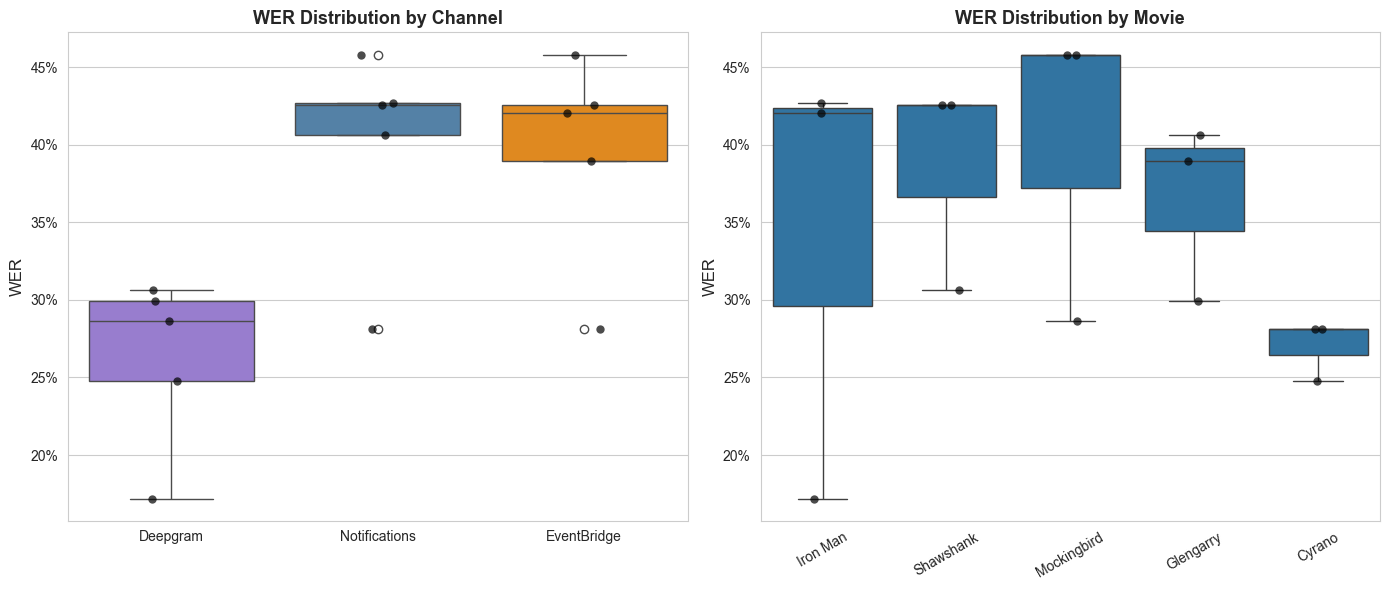


Mismatch document written to: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy/mismatches.md


In [10]:
# --- Descriptive Statistics ---
print("DESCRIPTIVE STATISTICS — WER BY CHANNEL")
print("=" * 70)
for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch_data = df_wer[df_wer["channel"] == channel]
    if ch_data.empty:
        continue
    wers = ch_data["wer"]
    print(f"\n  {channel}:")
    print(f"    Mean:   {wers.mean():.1%}")
    print(f"    Median: {wers.median():.1%}")
    print(f"    Std:    {wers.std():.1%}")
    print(f"    Min:    {wers.min():.1%}")
    print(f"    Max:    {wers.max():.1%}")
    print(f"    N:      {len(wers)}")

print("\n\nDESCRIPTIVE STATISTICS — WER BY MOVIE")
print("=" * 70)
for movie in sorted(df_wer["movie"].unique()):
    m_data = df_wer[df_wer["movie"] == movie]
    print(f"\n  {movie} (SRT: {m_data.iloc[0]['srt_type']}):")
    for channel in ["Deepgram", "Notifications", "EventBridge"]:
        ch = m_data[m_data["channel"] == channel]
        if not ch.empty:
            print(f"    {channel:<20} WER={ch.iloc[0]['wer']:.1%}  "
                  f"(S={ch.iloc[0]['substitutions']} D={ch.iloc[0]['deletions']} I={ch.iloc[0]['insertions']})")

# --- Confidence by WER bucket ---
print("\n\nCONFIDENCE BY WER BUCKET")
print("=" * 70)
df_wer["wer_bucket"] = pd.cut(
    df_wer["wer"],
    bins=[0, 0.10, 0.20, float("inf")],
    labels=["0-10%", "10-20%", "20%+"],
    include_lowest=True,
)
bucket_stats = df_wer.groupby("wer_bucket", observed=True)["confidence"].agg(["mean", "median", "count"])
print(bucket_stats.to_string())

# --- Box plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
channel_order = ["Deepgram", "Notifications", "EventBridge"]
palette = {"Deepgram": "mediumpurple", "Notifications": "steelblue", "EventBridge": "darkorange"}
sns.boxplot(data=df_wer, x="channel", y="wer", order=channel_order, palette=palette, ax=ax)
sns.stripplot(data=df_wer, x="channel", y="wer", order=channel_order, color="black",
              size=6, alpha=0.7, ax=ax, jitter=True)
ax.set_ylabel("WER", fontsize=12)
ax.set_xlabel("")
ax.set_title("WER Distribution by Channel", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

ax = axes[1]
sns.boxplot(data=df_wer, x="movie", y="wer", ax=ax)
sns.stripplot(data=df_wer, x="movie", y="wer", color="black", size=6, alpha=0.7, ax=ax, jitter=True)
ax.set_ylabel("WER", fontsize=12)
ax.set_xlabel("")
ax.set_title("WER Distribution by Movie", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "wer_distributions.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

# --- Mismatch Document (with alignment details) ---
mismatch_path = OUTPUT_DIR / "mismatches.md"
md_lines = [
    "# Transcription Mismatches — Session-Level WER Analysis\n",
    f"Generated from `transcription_accuracy-04-WER-ANALYSIS.ipynb`\n",
    "",
]

for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch_data = df_wer[(df_wer["channel"] == channel) & (df_wer["wer"] > 0)].sort_values("wer", ascending=False)
    md_lines.append(f"## {channel}\n")

    if ch_data.empty:
        md_lines.append("No mismatches (WER = 0 for all sessions).\n")
        continue

    for _, row in ch_data.iterrows():
        md_lines.append(f"### {row['movie']} — WER: {row['wer']:.1%}\n")
        md_lines.append(f"- **Session**: {row['dg_session']}")
        md_lines.append(f"- **Conv ID**: {row['conv_id']}")
        md_lines.append(f"- **SRT Type**: {row['srt_type']}")
        md_lines.append(f"- **Reference words**: {row['ref_words']}, Hypothesis words: {row['hyp_words']}")
        md_lines.append(f"- **Substitutions**: {row['substitutions']}, Deletions: {row['deletions']}, Insertions: {row['insertions']}")
        md_lines.append(f"- **Confidence**: {row['confidence']:.3f}")
        md_lines.append("")

        # Add alignment details
        measures = jiwer.process_words(row["reference"], row["hypothesis"])
        ref_w = measures.references[0]
        hyp_w = measures.hypotheses[0]

        md_lines.append("**Word-Level Errors:**\n")
        md_lines.append("| Type | Reference | Hypothesis | Category |")
        md_lines.append("|------|-----------|------------|----------|")

        error_count = 0
        for chunk in measures.alignments[0]:
            if chunk.type == "equal":
                continue
            elif chunk.type == "substitute":
                for ri, hi in zip(
                    range(chunk.ref_start_idx, chunk.ref_end_idx),
                    range(chunk.hyp_start_idx, chunk.hyp_end_idx),
                ):
                    cat = classify_word(ref_w[ri])
                    md_lines.append(f"| SUB | `{ref_w[ri]}` | `{hyp_w[hi]}` | {cat} |")
                    error_count += 1
            elif chunk.type == "delete":
                for ri in range(chunk.ref_start_idx, chunk.ref_end_idx):
                    cat = classify_word(ref_w[ri])
                    md_lines.append(f"| DEL | `{ref_w[ri]}` | — | {cat} |")
                    error_count += 1
            elif chunk.type == "insert":
                for hi in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                    cat = classify_word(hyp_w[hi])
                    md_lines.append(f"| INS | — | `{hyp_w[hi]}` | {cat} |")
                    error_count += 1
            if error_count >= 50:
                md_lines.append(f"| ... | _{measures.substitutions + measures.deletions + measures.insertions - error_count} more_ | | |")
                break

        md_lines.append("")
        md_lines.append("**Reference (SRT ground truth):**")
        md_lines.append(f"```")
        md_lines.append(row["reference"][:500])
        md_lines.append(f"```")
        md_lines.append("")
        md_lines.append("**Hypothesis (channel transcript):**")
        md_lines.append(f"```")
        md_lines.append(row["hypothesis"][:500])
        md_lines.append(f"```")
        md_lines.append("")

mismatch_path.write_text("\n".join(md_lines))
print(f"\nMismatch document written to: {mismatch_path}")

---
## Cell 10: Export Results

---
## Cell 9b: WER Pipeline Comparison Diagram

Summary visualization showing the full transcription pipeline: audio → ASR engines → delivery paths, with WER scores and error composition at each stage.

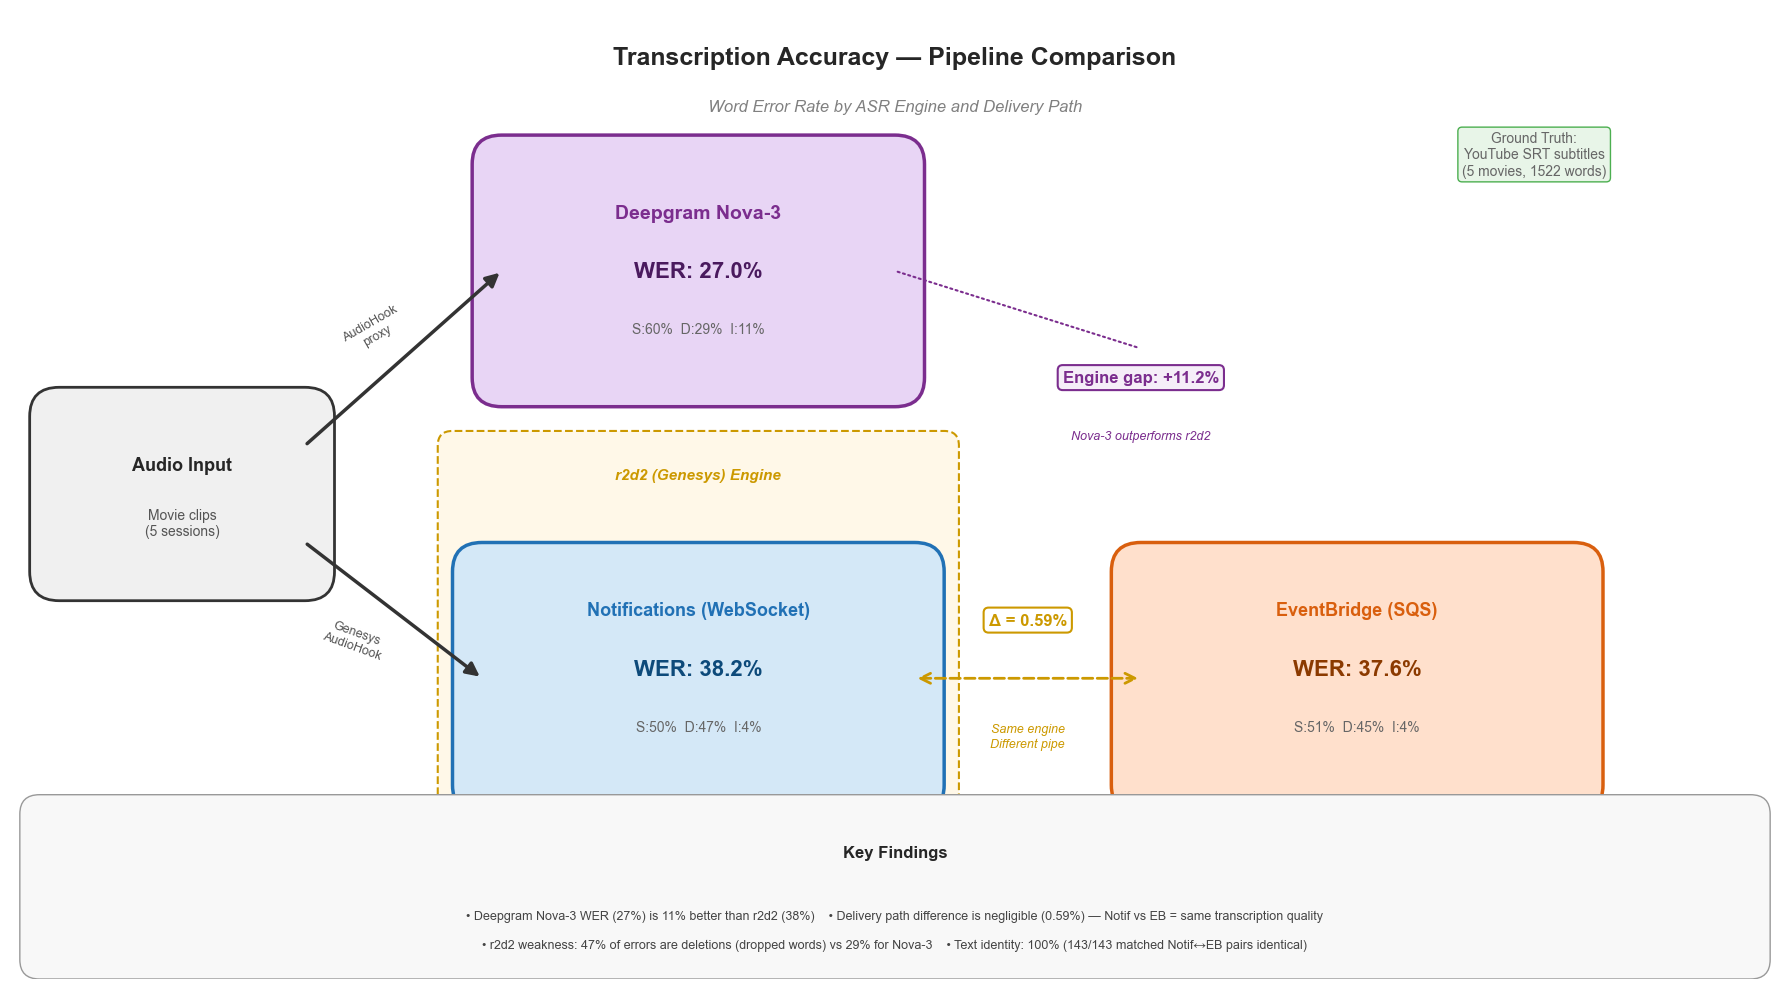

Pipeline diagram saved to: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy/wer_pipeline_diagram.png


In [11]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

# Compute summary stats from df_wer
def get_channel_stats(channel):
    ch = df_wer[df_wer["channel"] == channel]
    if ch.empty:
        return {}
    total_s = ch["substitutions"].sum()
    total_d = ch["deletions"].sum()
    total_i = ch["insertions"].sum()
    total_e = total_s + total_d + total_i
    total_ref = ch["ref_words"].sum()
    weighted_wer = total_e / total_ref if total_ref > 0 else 0
    return {
        "wer": weighted_wer,
        "sub_pct": total_s / total_e * 100 if total_e > 0 else 0,
        "del_pct": total_d / total_e * 100 if total_e > 0 else 0,
        "ins_pct": total_i / total_e * 100 if total_e > 0 else 0,
        "n_sessions": len(ch),
    }

dg_stats = get_channel_stats("Deepgram")
notif_stats = get_channel_stats("Notifications")
eb_stats = get_channel_stats("EventBridge")

# --- Title ---
ax.text(9, 9.5, "Transcription Accuracy — Pipeline Comparison",
        fontsize=18, fontweight="bold", ha="center", va="center")
ax.text(9, 9.0, "Word Error Rate by ASR Engine and Delivery Path",
        fontsize=12, color="gray", ha="center", va="center", style="italic")

# === BOXES ===
box_style = "round,pad=0.3"

# Audio source (left)
audio_box = FancyBboxPatch((0.5, 4.2), 2.5, 1.6, boxstyle=box_style,
                            facecolor="#f0f0f0", edgecolor="#333", linewidth=2)
ax.add_patch(audio_box)
ax.text(1.75, 5.3, "Audio Input", fontsize=13, fontweight="bold", ha="center", va="center")
ax.text(1.75, 4.7, "Movie clips\n(5 sessions)", fontsize=10, ha="center", va="center", color="#555")

# Deepgram box (top center)
dg_box = FancyBboxPatch((5.0, 6.2), 4.0, 2.2, boxstyle=box_style,
                          facecolor="#e8d5f5", edgecolor="#7b2d8e", linewidth=2.5)
ax.add_patch(dg_box)
ax.text(7.0, 7.9, "Deepgram Nova-3", fontsize=14, fontweight="bold", ha="center", va="center",
        color="#7b2d8e")
ax.text(7.0, 7.3, f"WER: {dg_stats['wer']:.1%}", fontsize=16, fontweight="bold", ha="center",
        va="center", color="#4a1a5e")
ax.text(7.0, 6.7, f"S:{dg_stats['sub_pct']:.0f}%  D:{dg_stats['del_pct']:.0f}%  I:{dg_stats['ins_pct']:.0f}%",
        fontsize=10, ha="center", va="center", color="#666")

# r2d2 engine group box (faint background)
r2d2_bg = FancyBboxPatch((4.5, 1.0), 5.0, 4.5, boxstyle="round,pad=0.15",
                           facecolor="#fff8e8", edgecolor="#cc9900", linewidth=1.5, linestyle="--")
ax.add_patch(r2d2_bg)
ax.text(7.0, 5.2, "r2d2 (Genesys) Engine", fontsize=11, fontweight="bold",
        ha="center", va="center", color="#cc9900", style="italic")

# Notifications box (bottom left)
notif_box = FancyBboxPatch((4.8, 2.0), 4.4, 2.2, boxstyle=box_style,
                             facecolor="#d4e8f7", edgecolor="#2171b5", linewidth=2.5)
ax.add_patch(notif_box)
ax.text(7.0, 3.8, "Notifications (WebSocket)", fontsize=13, fontweight="bold", ha="center",
        va="center", color="#2171b5")
ax.text(7.0, 3.2, f"WER: {notif_stats['wer']:.1%}", fontsize=16, fontweight="bold", ha="center",
        va="center", color="#0d4a7a")
ax.text(7.0, 2.6, f"S:{notif_stats['sub_pct']:.0f}%  D:{notif_stats['del_pct']:.0f}%  I:{notif_stats['ins_pct']:.0f}%",
        fontsize=10, ha="center", va="center", color="#666")

# EventBridge box (right)
eb_box = FancyBboxPatch((11.5, 2.0), 4.4, 2.2, boxstyle=box_style,
                          facecolor="#ffe0cc", edgecolor="#d95f0e", linewidth=2.5)
ax.add_patch(eb_box)
ax.text(13.7, 3.8, "EventBridge (SQS)", fontsize=13, fontweight="bold", ha="center",
        va="center", color="#d95f0e")
ax.text(13.7, 3.2, f"WER: {eb_stats['wer']:.1%}", fontsize=16, fontweight="bold", ha="center",
        va="center", color="#8b3a00")
ax.text(13.7, 2.6, f"S:{eb_stats['sub_pct']:.0f}%  D:{eb_stats['del_pct']:.0f}%  I:{eb_stats['ins_pct']:.0f}%",
        fontsize=10, ha="center", va="center", color="#666")

# === ARROWS ===
arrow_kw = dict(arrowstyle="-|>", color="#333", linewidth=2.5, mutation_scale=20)

# Audio → Deepgram
ax.annotate("", xy=(5.0, 7.3), xytext=(3.0, 5.5), arrowprops=arrow_kw)
ax.text(3.7, 6.7, "AudioHook\nproxy", fontsize=9, ha="center", va="center", color="#555",
        rotation=30)

# Audio → r2d2/Notif
ax.annotate("", xy=(4.8, 3.1), xytext=(3.0, 4.5), arrowprops=arrow_kw)
ax.text(3.5, 3.5, "Genesys\nAudioHook", fontsize=9, ha="center", va="center", color="#555",
        rotation=-20)

# Notif → EB (same engine, different delivery)
ax.annotate("", xy=(11.5, 3.1), xytext=(9.2, 3.1),
            arrowprops=dict(arrowstyle="<->", color="#cc9900", linewidth=2, mutation_scale=18,
                            linestyle="--"))

# Delta label between Notif and EB
notif_eb_delta = abs(notif_stats["wer"] - eb_stats["wer"])
ax.text(10.35, 3.7, f"Δ = {notif_eb_delta:.2%}", fontsize=12, fontweight="bold",
        ha="center", va="center", color="#cc9900",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cc9900", linewidth=1.5))
ax.text(10.35, 2.5, "Same engine\nDifferent pipe", fontsize=9, ha="center", va="center",
        color="#cc9900", style="italic")

# Engine comparison delta (Deepgram vs r2d2)
dg_r2d2_delta = notif_stats["wer"] - dg_stats["wer"]
ax.text(11.5, 6.2, f"Engine gap: {dg_r2d2_delta:+.1%}",
        fontsize=12, fontweight="bold", ha="center", va="center", color="#7b2d8e",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5eef8", edgecolor="#7b2d8e", linewidth=1.5))
ax.text(11.5, 5.6, "Nova-3 outperforms r2d2", fontsize=9, ha="center", va="center",
        color="#7b2d8e", style="italic")

# Arrow from DG box to engine gap label
ax.annotate("", xy=(11.5, 6.5), xytext=(9.0, 7.3),
            arrowprops=dict(arrowstyle="-", color="#7b2d8e", linewidth=1.5, linestyle=":"))

# === KEY FINDINGS BOX (bottom) ===
findings_box = FancyBboxPatch((0.3, 0.2), 17.4, 1.5, boxstyle="round,pad=0.2",
                                facecolor="#f8f8f8", edgecolor="#999", linewidth=1)
ax.add_patch(findings_box)
ax.text(9, 1.3, "Key Findings", fontsize=12, fontweight="bold", ha="center", va="center")

findings = [
    f"• Deepgram Nova-3 WER ({dg_stats['wer']:.0%}) is {dg_r2d2_delta:.0%} better than r2d2 ({notif_stats['wer']:.0%})",
    f"• Delivery path difference is negligible ({notif_eb_delta:.2%}) — Notif vs EB = same transcription quality",
    f"• r2d2 weakness: {notif_stats['del_pct']:.0f}% of errors are deletions (dropped words) vs {dg_stats['del_pct']:.0f}% for Nova-3",
    f"• Text identity: 100% ({total_pairs}/{total_pairs} matched Notif↔EB pairs identical)",
]
ax.text(9, 0.65, "    ".join(findings[:2]), fontsize=9, ha="center", va="center", color="#444")
ax.text(9, 0.35, "    ".join(findings[2:]), fontsize=9, ha="center", va="center", color="#444")

# === GROUND TRUTH LABEL ===
ax.text(15.5, 8.5, "Ground Truth:\nYouTube SRT subtitles\n(5 movies, 1522 words)",
        fontsize=10, ha="center", va="center", color="#666",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f5e8", edgecolor="#4CAF50", linewidth=1))

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "wer_pipeline_diagram.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"Pipeline diagram saved to: {OUTPUT_DIR / 'wer_pipeline_diagram.png'}")

In [12]:
# --- CSV export ---
csv_path = OUTPUT_DIR / "session_wer.csv"
export_cols = [
    "movie", "srt_type", "channel", "conv_id", "dg_session",
    "wer", "substitutions", "deletions", "insertions", "hits",
    "ref_words", "hyp_words", "confidence",
]
df_wer[export_cols].to_csv(csv_path, index=False)
print(f"CSV exported: {csv_path}")

# --- JSON summary ---
summary = {
    "focus": "session_level_wer_analysis",
    "movies": sorted(df_wer["movie"].unique().tolist()),
    "channels": ["Deepgram", "Notifications", "EventBridge"],
    "wer_by_channel": {},
    "wer_by_movie": {},
    "dropped_utterances": {
        "total": len(df_dropped),
        "by_missing_from": df_dropped["missing_from"].value_counts().to_dict() if not df_dropped.empty else {},
    },
    "text_identity": {
        "total_pairs": total_pairs,
        "identical": identical_pairs,
        "different": len(identity_rows),
        "identity_rate": identical_pairs / total_pairs if total_pairs > 0 else 0,
    },
}

for channel in ["Deepgram", "Notifications", "EventBridge"]:
    ch_data = df_wer[df_wer["channel"] == channel]
    if ch_data.empty:
        continue
    wers = ch_data["wer"]
    total_errors = ch_data["substitutions"].sum() + ch_data["deletions"].sum() + ch_data["insertions"].sum()
    total_ref = ch_data["ref_words"].sum()
    summary["wer_by_channel"][channel] = {
        "mean_wer": round(float(wers.mean()), 4),
        "median_wer": round(float(wers.median()), 4),
        "std_wer": round(float(wers.std()), 4),
        "min_wer": round(float(wers.min()), 4),
        "max_wer": round(float(wers.max()), 4),
        "weighted_wer": round(float(total_errors / total_ref), 4) if total_ref > 0 else 0,
        "n_sessions": len(ch_data),
        "total_ref_words": int(total_ref),
        "mean_confidence": round(float(ch_data["confidence"].mean()), 4),
    }

for movie in sorted(df_wer["movie"].unique()):
    m_data = df_wer[df_wer["movie"] == movie]
    movie_entry = {"srt_type": m_data.iloc[0]["srt_type"]}
    for channel in ["Deepgram", "Notifications", "EventBridge"]:
        ch = m_data[m_data["channel"] == channel]
        if not ch.empty:
            row = ch.iloc[0]
            movie_entry[channel] = {
                "wer": round(float(row["wer"]), 4),
                "substitutions": int(row["substitutions"]),
                "deletions": int(row["deletions"]),
                "insertions": int(row["insertions"]),
                "ref_words": int(row["ref_words"]),
                "confidence": round(float(row["confidence"]), 4),
            }
    summary["wer_by_movie"][movie] = movie_entry

json_path = OUTPUT_DIR / "wer_summary.json"
json_path.write_text(json.dumps(summary, indent=2))
print(f"JSON exported: {json_path}")

# --- List all outputs ---
print(f"\nAll outputs in {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")

CSV exported: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy/session_wer.csv
JSON exported: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy/wer_summary.json

All outputs in /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/transcription_accuracy:
  error_by_category.png
  error_type_breakdown.png
  mismatches.md
  session_wer.csv
  wer_distributions.png
  wer_pipeline_diagram.png
  wer_summary.json
  wer_vs_confidence.png
